# Capítulo 30 — Errores comunes al construir modelos

En este cuaderno retomaremos explícitamente el ejemplo de **abandono de clientes** utilizado en el capítulo teórico. No aprenderemos un algoritmo nuevo: auditaremos un proyecto completo para reconocer resultados que parecen buenos, pero fueron obtenidos con un procedimiento incorrecto.

Primero construiremos algunos errores de manera deliberada. Después corregiremos el flujo y comprobaremos cómo cambia lo que podemos afirmar. El dataset será sintético para que podamos incorporar fugas, cambios temporales y registros relacionados sin confundirlos con hechos sobre clientes reales.


## Objetivos del cuaderno

Al finalizar, deberías poder:

- distinguir desempeño de entrenamiento y capacidad de generalización;
- reservar datos futuros para una evaluación final;
- reconocer variables posteriores al evento;
- explicar por qué las transformaciones deben aprenderse dentro de un pipeline;
- detectar contaminación en selección de variables y validación cruzada;
- elegir métricas según el costo de los errores;
- comparar modelos con los mismos folds y criterios;
- comprobar la variabilidad entre divisiones;
- separar entidades relacionadas mediante grupos;
- revisar falsos positivos, falsos negativos y errores confiados;
- comunicar resultados sin convertir asociaciones o métricas en certezas.


## 1. Importar las herramientas

Usaremos Pandas y NumPy para construir los datos, Matplotlib para visualizar y `scikit-learn` para preparar, entrenar y evaluar los modelos.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Construir un historial de clientes

Cada fila representa la información disponible en una fecha de corte. La variable objetivo `abandono` indica si el cliente abandonó durante el período siguiente.

Para que la evaluación temporal sea significativa, los seis meses finales tendrán un comportamiento algo más difícil de predecir. Esto representa un cambio de contexto: los datos futuros no siempre se comportan exactamente como el pasado.


In [2]:
generador = np.random.default_rng(30)
n = 6_000

mes = np.sort(generador.integers(1, 37, n))
antiguedad = np.clip(
    generador.gamma(3.2, 9.0, n) + 0.35 * mes, 1, 120
)
cargo_mensual = np.clip(generador.normal(72, 22, n), 18, 160)
reclamos_6m = np.clip(generador.poisson(0.75, n), 0, 7)
tickets_soporte = np.clip(
    generador.poisson(1.2 + 0.18 * reclamos_6m), 0, 10
)
caida_uso_pct = np.clip(
    generador.normal(12 + 4.5 * reclamos_6m, 14, n), 0, 85
)
ingreso_estimado = np.clip(
    generador.lognormal(np.log(1_100), 0.48, n), 250, 5_000
)
contrato = generador.choice(
    ["Mensual", "Anual", "Bienal"], n, p=[0.58, 0.30, 0.12]
)
canal = generador.choice(
    ["Web", "Movil", "Telefonico"], n, p=[0.45, 0.40, 0.15]
)

logit = (
    -3.15
    + 0.46 * reclamos_6m
    + 0.030 * caida_uso_pct
    + 0.16 * tickets_soporte
    + 0.007 * (cargo_mensual - 70)
    - 0.020 * antiguedad
    + 0.90 * (contrato == "Mensual")
    - 0.45 * (contrato == "Bienal")
    + 0.20 * (canal == "Telefonico")
)

# Los meses finales contienen más variabilidad no explicada.
ruido = generador.normal(0, np.where(mes <= 30, 0.55, 1.45))
probabilidad = 1 / (1 + np.exp(-(logit + ruido)))
abandono = generador.binomial(1, probabilidad)

clientes = pd.DataFrame({
    "mes": mes,
    "antiguedad_meses": antiguedad.round(1),
    "cargo_mensual": cargo_mensual.round(2),
    "reclamos_6m": reclamos_6m,
    "tickets_soporte": tickets_soporte,
    "caida_uso_pct": caida_uso_pct.round(1),
    "ingreso_estimado": ingreso_estimado.round(2),
    "contrato": contrato,
    "canal": canal,
    "abandono": abandono,
})

# El registro de ingresos se vuelve menos completo en el período reciente.
prob_faltante = np.where(clientes["mes"] <= 24, 0.05, 0.16)
clientes.loc[
    generador.random(n) < prob_faltante, "ingreso_estimado"
] = np.nan

# Esta columna existe después del evento y NO debería usarse para predecir.
clientes["baja_confirmada"] = np.where(
    generador.random(n) < 0.985,
    clientes["abandono"],
    1 - clientes["abandono"],
)

clientes.head(8)


,mes,antiguedad_meses,cargo_mensual,reclamos_6m,tickets_soporte,caida_uso_pct,ingreso_estimado,contrato,canal,abandono,baja_confirmada
0,1,34.900,83.650,1,0,17.700,537.290,Anual,Telefonico,0,0
1,1,6.500,42.660,3,2,4.000,932.670,Bienal,Web,0,0
2,1,8.700,77.730,0,1,8.800,"1,305.200",Mensual,Web,0,0
3,1,17.800,98.380,0,2,0.000,"1,047.400",Mensual,Movil,0,0
4,1,43.400,39.950,1,2,23.200,"1,035.590",Anual,Web,0,0
5,1,10.800,81.110,3,2,25.200,"1,537.500",Mensual,Web,0,0
6,1,27.100,50.120,0,1,6.900,"1,620.540",Mensual,Web,0,0
7,1,34.700,103.370,1,0,8.100,NaN,Mensual,Web,0,0


`baja_confirmada` fue construida después del resultado y prácticamente revela la respuesta. La mantendremos únicamente para demostrar una fuga de datos.


In [3]:
resumen = pd.DataFrame({
    "filas": [len(clientes)],
    "mes_inicial": [clientes["mes"].min()],
    "mes_final": [clientes["mes"].max()],
    "proporcion_abandono": [clientes["abandono"].mean()],
    "faltantes_ingreso": [clientes["ingreso_estimado"].isna().mean()],
})
print(resumen.to_string(index=False))

por_periodo = (
    clientes.assign(
        periodo=np.where(clientes["mes"] <= 30, "Desarrollo", "Test final")
    )
    .groupby("periodo", as_index=False)
    .agg(
        casos=("abandono", "size"),
        proporcion_abandono=("abandono", "mean"),
        faltantes_ingreso=("ingreso_estimado", lambda s: s.isna().mean()),
    )
)
por_periodo


 filas  mes_inicial  mes_final  proporcion_abandono  faltantes_ingreso
  6000            1         36                0.131              0.089


,periodo,casos,proporcion_abandono,faltantes_ingreso
0,Desarrollo,4982,0.123,0.079
1,Test final,1018,0.174,0.142


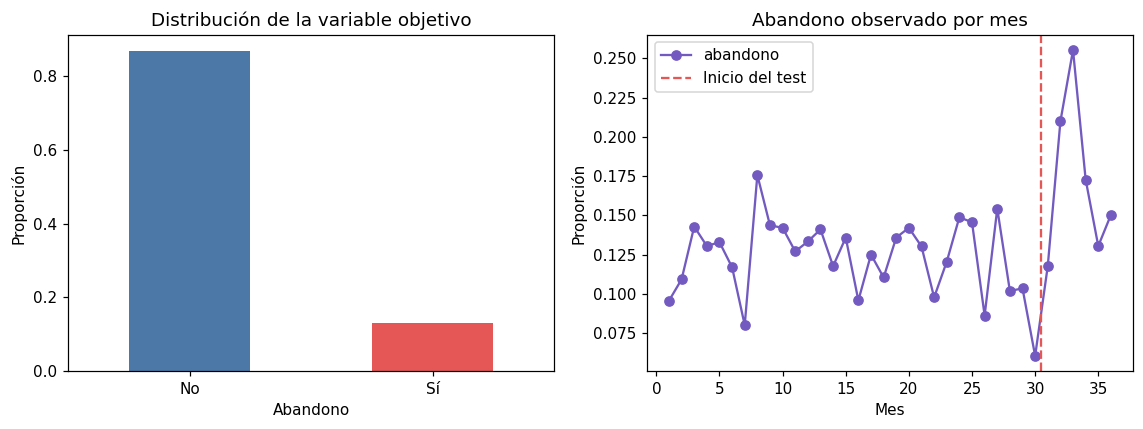

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))

clientes["abandono"].value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=axes[0], color=["#4C78A8", "#E45756"]
)
axes[0].set_title("Distribución de la variable objetivo")
axes[0].set_xlabel("Abandono")
axes[0].set_ylabel("Proporción")
axes[0].set_xticklabels(["No", "Sí"], rotation=0)

clientes.groupby("mes")["abandono"].mean().plot(
    ax=axes[1], marker="o", color="#725AC1"
)
axes[1].axvline(30.5, color="#E45756", linestyle="--", label="Inicio del test")
axes[1].set_title("Abandono observado por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Proporción")
axes[1].legend()

plt.tight_layout()
plt.show()


La clase positiva es minoritaria. Por lo tanto, accuracy por sí sola puede ser engañosa. Además, el gráfico temporal recuerda que la evaluación debe respetar el escenario futuro.


## 3. Reservar el test final antes de experimentar

Los meses 1 a 30 formarán el conjunto de desarrollo. Los meses 31 a 36 quedarán reservados hasta que terminemos de elegir el procedimiento.


In [5]:
desarrollo = clientes[clientes["mes"] <= 30].copy()
test_final = clientes[clientes["mes"] > 30].copy()

objetivo = "abandono"
variables_validas = [
    "antiguedad_meses",
    "cargo_mensual",
    "reclamos_6m",
    "tickets_soporte",
    "caida_uso_pct",
    "ingreso_estimado",
    "contrato",
    "canal",
]
numericas = [
    "antiguedad_meses",
    "cargo_mensual",
    "reclamos_6m",
    "tickets_soporte",
    "caida_uso_pct",
    "ingreso_estimado",
]
categoricas = ["contrato", "canal"]

X_desarrollo = desarrollo[variables_validas]
y_desarrollo = desarrollo[objetivo]
X_final = test_final[variables_validas]
y_final = test_final[objetivo]

print(f"Desarrollo: {len(desarrollo):,} filas")
print(f"Test final reservado: {len(test_final):,} filas")


Desarrollo: 4,982 filas
Test final reservado: 1,018 filas


## 4. Error: entrenar y evaluar con los mismos datos

Un árbol profundo puede memorizar particularidades del entrenamiento. Compararemos su F1 sobre datos conocidos con el F1 sobre una división no vista del conjunto de desarrollo.


In [6]:
X_train_demo, X_valid_demo, y_train_demo, y_valid_demo = train_test_split(
    X_desarrollo,
    y_desarrollo,
    test_size=0.25,
    stratify=y_desarrollo,
    random_state=30,
)

preprocesamiento_arbol = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numericas),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), categoricas),
])

arbol_profundo = Pipeline([
    ("preprocesamiento", preprocesamiento_arbol),
    ("modelo", DecisionTreeClassifier(random_state=30)),
])
arbol_profundo.fit(X_train_demo, y_train_demo)

resultados_memoria = pd.DataFrame({
    "Evaluación": ["Mismos datos de entrenamiento", "Validación no vista"],
    "Accuracy": [
        accuracy_score(y_train_demo, arbol_profundo.predict(X_train_demo)),
        accuracy_score(y_valid_demo, arbol_profundo.predict(X_valid_demo)),
    ],
    "F1": [
        f1_score(y_train_demo, arbol_profundo.predict(X_train_demo)),
        f1_score(y_valid_demo, arbol_profundo.predict(X_valid_demo)),
    ],
})
resultados_memoria


,Evaluación,Accuracy,F1
0,Mismos datos de entrenamiento,1.000,1.000
1,Validación no vista,0.783,0.161


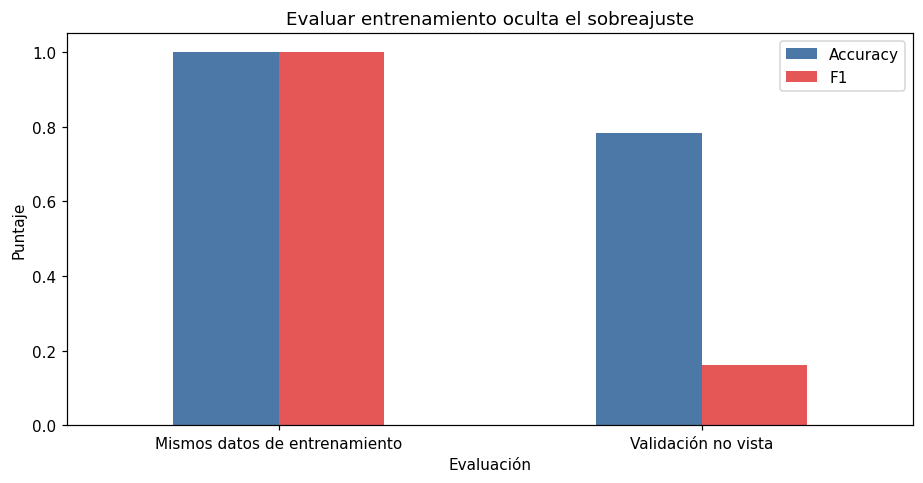

In [7]:
ax = resultados_memoria.set_index("Evaluación")[["Accuracy", "F1"]].plot(
    kind="bar", figsize=(8.5, 4.5), color=["#4C78A8", "#E45756"]
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Puntaje")
ax.set_title("Evaluar entrenamiento oculta el sobreajuste")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


El árbol obtiene F1 `1,000` sobre los mismos datos usados para entrenar, pero baja a `0,161` cuando recibe casos no vistos. El primer resultado describe cuánto ajustó los ejemplos conocidos; la caída en validación muestra por qué esa métrica no puede presentarse como desempeño futuro.


## 5. Error: permitir una variable posterior al evento

Ahora compararemos una regresión logística con variables disponibles antes de predecir y otra que recibe `baja_confirmada`. Usaremos los mismos folds y la misma métrica.


In [8]:
def crear_preprocesamiento(columnas_numericas, columnas_categoricas):
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), columnas_numericas),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), columnas_categoricas),
    ])


def crear_logistica(columnas_numericas=numericas,
                    columnas_categoricas=categoricas):
    return Pipeline([
        ("preprocesamiento", crear_preprocesamiento(
            columnas_numericas, columnas_categoricas
        )),
        ("modelo", LogisticRegression(
            max_iter=2_000, class_weight="balanced", random_state=30
        )),
    ])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=30)
modelo_valido = crear_logistica()
modelo_con_fuga = crear_logistica(
    numericas + ["baja_confirmada"], categoricas
)

comparacion_fuga = []
for nombre, modelo, columnas in [
    ("Variables disponibles", modelo_valido, variables_validas),
    ("Incluye baja_confirmada", modelo_con_fuga,
     variables_validas + ["baja_confirmada"]),
]:
    scores = cross_validate(
        modelo,
        desarrollo[columnas],
        y_desarrollo,
        cv=cv,
        scoring={"accuracy": "accuracy", "f1": "f1", "recall": "recall"},
    )
    comparacion_fuga.append({
        "Flujo": nombre,
        "Accuracy media": scores["test_accuracy"].mean(),
        "F1 medio": scores["test_f1"].mean(),
        "Recall medio": scores["test_recall"].mean(),
    })

comparacion_fuga = pd.DataFrame(comparacion_fuga)
comparacion_fuga


,Flujo,Accuracy media,F1 medio,Recall medio
0,Variables disponibles,0.682,0.339,0.666
1,Incluye baja_confirmada,0.987,0.950,0.984


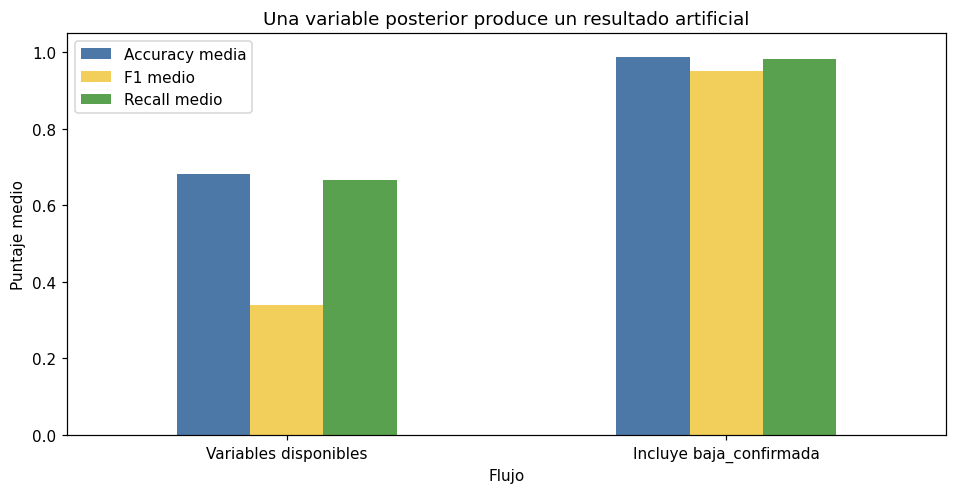

In [9]:
ax = comparacion_fuga.set_index("Flujo").plot(
    kind="bar", figsize=(8.8, 4.6),
    color=["#4C78A8", "#F2CF5B", "#59A14F"]
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Puntaje medio")
ax.set_title("Una variable posterior produce un resultado artificial")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


Con variables disponibles, el F1 medio es `0,339`. Al agregar la columna posterior, sube artificialmente a `0,950`. La mejora casi perfecta no demuestra que el problema sea fácil: revela que el modelo recibió información que no existiría en el momento real de predicción. Un resultado demasiado bueno merece una auditoría de variables, fechas y separación.


## 6. Error: aprender el preprocesamiento antes de validar

El efecto de escalar con todo el dataset puede ser pequeño en algunos conjuntos. Para hacer visible el problema general, construiremos un ejemplo auxiliar con muchas variables irrelevantes y aplicaremos selección automática.

En el flujo incorrecto, `SelectKBest` mira todo `X` e `y` antes de la validación cruzada. En el correcto, la selección queda dentro del pipeline y se repite desde cero en cada fold.


In [10]:
g_aux = np.random.default_rng(300)
n_aux, p_ruido = 280, 500

senal_1 = g_aux.normal(size=n_aux)
senal_2 = g_aux.normal(size=n_aux)
y_aux = (
    1.0 * senal_1 - 0.7 * senal_2 + g_aux.normal(0, 1.5, n_aux) > 0
).astype(int)
X_aux = np.column_stack([
    senal_1, senal_2, g_aux.normal(size=(n_aux, p_ruido))
])

selector_incorrecto = SelectKBest(f_classif, k=12)
X_seleccionado_antes = selector_incorrecto.fit_transform(X_aux, y_aux)

modelo_aux = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2_000, random_state=30)),
])
flujo_correcto = Pipeline([
    ("selector", SelectKBest(f_classif, k=12)),
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2_000, random_state=30)),
])

cv_aux = StratifiedKFold(n_splits=5, shuffle=True, random_state=30)
score_incorrecto = cross_validate(
    modelo_aux, X_seleccionado_antes, y_aux, cv=cv_aux, scoring="f1"
)["test_score"]
score_correcto = cross_validate(
    flujo_correcto, X_aux, y_aux, cv=cv_aux, scoring="f1"
)["test_score"]

pd.DataFrame({
    "Procedimiento": [
        "Selección antes de validar",
        "Selección dentro del pipeline",
    ],
    "F1 medio": [score_incorrecto.mean(), score_correcto.mean()],
    "Desviación": [score_incorrecto.std(), score_correcto.std()],
})


,Procedimiento,F1 medio,Desviación
0,Selección antes de validar,0.686,0.059
1,Selección dentro del pipeline,0.609,0.068


La selección incorrecta informa F1 `0,686`, frente a `0,609` cuando se repite correctamente dentro de cada fold. Eligió variables después de mirar también los casos que pretendíamos usar como evaluación. Lo mismo puede ocurrir con imputación, escalado, codificación o PCA. La regla práctica es: **todo paso que use `fit` debe aprender solo desde la parte de entrenamiento correspondiente**.


## 7. Error: elegir accuracy sin pensar en el objetivo

Compararemos una referencia que siempre predice la clase mayoritaria con la regresión logística. Si miráramos solo accuracy, la referencia podría parecer razonable aunque no detecte abandonos.


In [11]:
modelos_metricas = {
    "Siempre clase mayoritaria": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": modelo_valido,
}

scorers_sin_advertencias = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

comparacion_metricas = []
for nombre, modelo in modelos_metricas.items():
    scores = cross_validate(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring=scorers_sin_advertencias,
    )
    comparacion_metricas.append({
        "Modelo": nombre,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
    })

comparacion_metricas = pd.DataFrame(comparacion_metricas)
comparacion_metricas


,Modelo,Accuracy,Precision,Recall,F1
0,Siempre clase mayoritaria,0.877,0.000,0.000,0.000
1,Regresión logística,0.682,0.228,0.666,0.339


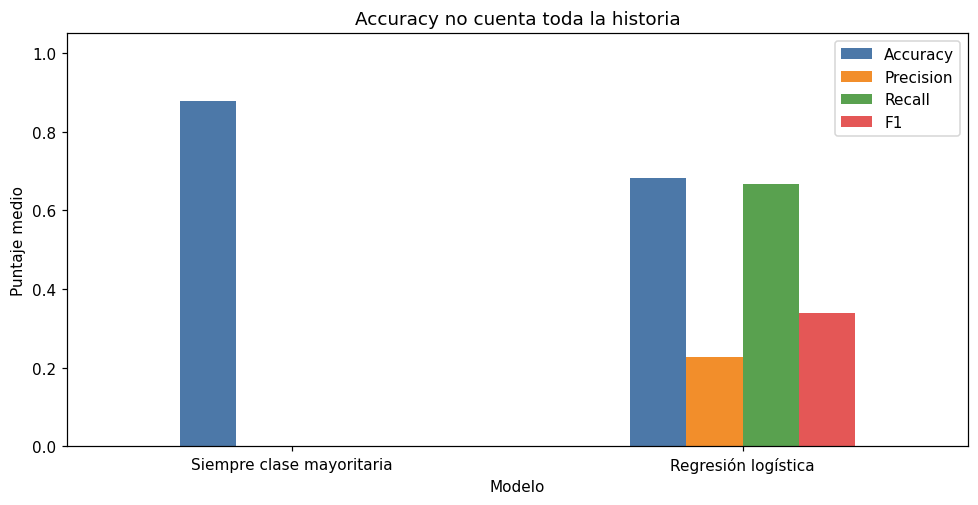

In [12]:
ax = comparacion_metricas.set_index("Modelo").plot(
    kind="bar", figsize=(9, 4.7),
    color=["#4C78A8", "#F28E2B", "#59A14F", "#E45756"]
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Puntaje medio")
ax.set_title("Accuracy no cuenta toda la historia")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


La referencia alcanza accuracy `0,877`, pero recall y F1 iguales a cero: no detecta ningún abandono. La métrica principal depende del uso. En este ejemplo elegiremos F1 para equilibrar precision y recall, pero una organización podría priorizar recall si omitir un abandono fuera especialmente costoso. Esa decisión debería definirse antes de destacar el resultado más favorable.


## 8. Comparar modelos en condiciones equivalentes

Cada algoritmo recibirá un flujo adecuado: la regresión logística incluye escalado; los árboles no lo necesitan. Todos usarán las mismas variables, los mismos folds y las mismas métricas.


In [13]:
preprocesamiento_sin_escala = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numericas),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), categoricas),
])

modelos_justos = {
    "Regresión logística": modelo_valido,
    "Árbol profundidad 5": Pipeline([
        ("preprocesamiento", preprocesamiento_sin_escala),
        ("modelo", DecisionTreeClassifier(
            max_depth=5, min_samples_leaf=15, random_state=30
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocesamiento", preprocesamiento_sin_escala),
        ("modelo", RandomForestClassifier(
            n_estimators=220,
            max_depth=8,
            min_samples_leaf=8,
            class_weight="balanced",
            n_jobs=-1,
            random_state=30,
        )),
    ]),
}

filas_comparacion = []
scores_por_modelo = {}
for nombre, modelo in modelos_justos.items():
    scores = cross_validate(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring={"accuracy": "accuracy", "f1": "f1", "recall": "recall"},
    )
    scores_por_modelo[nombre] = scores["test_f1"]
    filas_comparacion.append({
        "Modelo": nombre,
        "Accuracy media": scores["test_accuracy"].mean(),
        "F1 medio": scores["test_f1"].mean(),
        "F1 desviación": scores["test_f1"].std(),
        "Recall medio": scores["test_recall"].mean(),
    })

comparacion_justa = pd.DataFrame(filas_comparacion).sort_values(
    "F1 medio", ascending=False
)
comparacion_justa


,Modelo,Accuracy media,F1 medio,F1 desviación,Recall medio
2,Random Forest,0.770,0.345,0.019,0.494
0,Regresión logística,0.682,0.339,0.014,0.666
1,Árbol profundidad 5,0.873,0.057,0.042,0.033


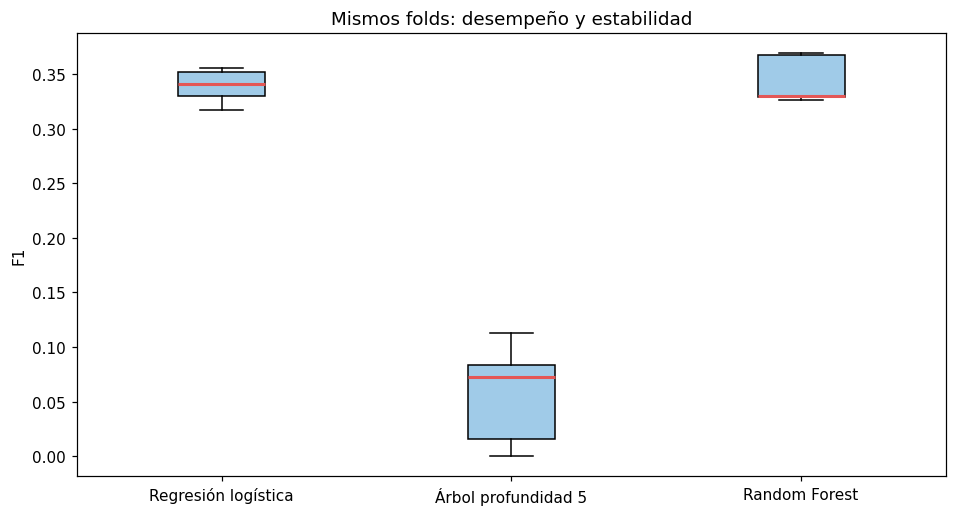

In [14]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.boxplot(
    [scores_por_modelo[n] for n in modelos_justos],
    tick_labels=list(modelos_justos),
    patch_artist=True,
    boxprops={"facecolor": "#A0CBE8"},
    medianprops={"color": "#E45756", "linewidth": 2},
)
ax.set_ylabel("F1")
ax.set_title("Mismos folds: desempeño y estabilidad")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


Random Forest obtiene F1 medio `0,345` y la regresión logística `0,339`: una diferencia demasiado pequeña para afirmar superioridad sin mirar variabilidad, complejidad y errores. Además, la regresión logística logra un recall claramente mayor. Aquí comparamos **pipelines completos**, no algoritmos aislados de su preparación.


## 9. No confiar en una única división

Para observar cuánto depende una métrica de la partición, repetiremos quince divisiones estratificadas. El test final continúa intacto: todas las repeticiones usan solo el conjunto de desarrollo.


In [15]:
resultados_semillas = []
for semilla in range(15):
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_desarrollo,
        y_desarrollo,
        test_size=0.25,
        stratify=y_desarrollo,
        random_state=semilla,
    )
    modelo_semilla = crear_logistica()
    modelo_semilla.fit(X_tr, y_tr)
    pred = modelo_semilla.predict(X_va)
    resultados_semillas.append({
        "semilla": semilla,
        "F1": f1_score(y_va, pred),
        "Recall": recall_score(y_va, pred),
    })

resultados_semillas = pd.DataFrame(resultados_semillas)
print(resultados_semillas.describe().loc[["mean", "std", "min", "max"]])
resultados_semillas


      semilla    F1  Recall
mean    7.000 0.340   0.668
std     4.472 0.014   0.034
min     0.000 0.306   0.588
max    14.000 0.361   0.719


,semilla,F1,Recall
0,0,0.355,0.686
1,1,0.361,0.699
2,2,0.344,0.667
3,3,0.306,0.588
4,4,0.328,0.641
5,5,0.339,0.654
6,6,0.317,0.614
7,7,0.344,0.680
8,8,0.333,0.654
9,9,0.351,0.680


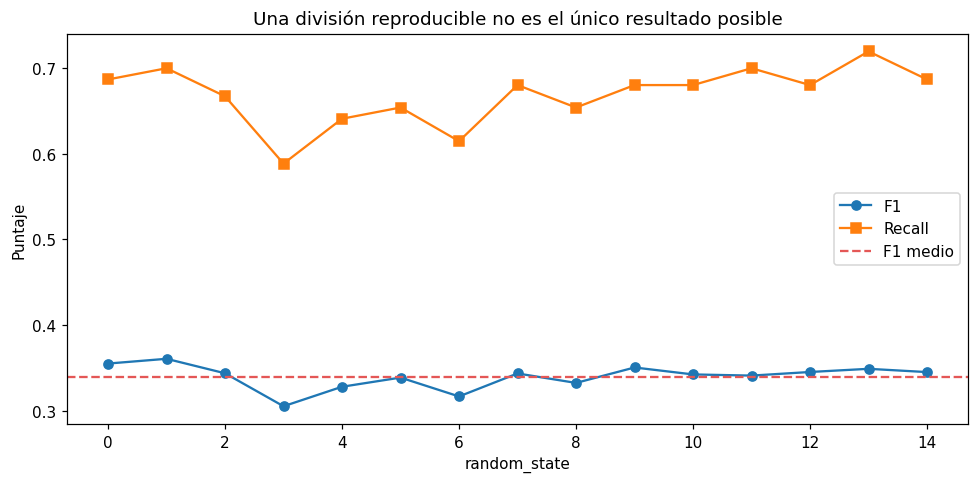

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    resultados_semillas["semilla"],
    resultados_semillas["F1"],
    marker="o",
    label="F1",
)
ax.plot(
    resultados_semillas["semilla"],
    resultados_semillas["Recall"],
    marker="s",
    label="Recall",
)
ax.axhline(
    resultados_semillas["F1"].mean(),
    color="#E45756",
    linestyle="--",
    label="F1 medio",
)
ax.set_xlabel("random_state")
ax.set_ylabel("Puntaje")
ax.set_title("Una división reproducible no es el único resultado posible")
ax.legend()
plt.tight_layout()
plt.show()


`random_state` permite reproducir una división, pero no la vuelve representativa por sí sola. La validación cruzada y la dispersión entre resultados ofrecen una descripción más honesta que un único número.


## 10. Registros relacionados: separar por cliente

El capítulo advierte que varias filas de la misma entidad no deberían repartirse entre entrenamiento y prueba cuando el uso futuro exige generalizar a entidades nuevas.

Crearemos cuatro registros por cliente y, de manera deliberadamente incorrecta, entregaremos `cliente_id` al modelo. Una división aleatoria permite memorizar clientes. Una separación por grupos coloca clientes completos en uno u otro conjunto.


In [17]:
g_grupos = np.random.default_rng(3030)
n_clientes = 520
observaciones = 4

id_cliente = np.repeat(
    [f"C{i:04d}" for i in range(n_clientes)], observaciones
)
abandono_cliente = g_grupos.binomial(1, 0.18, n_clientes)
y_grupos = np.repeat(abandono_cliente, observaciones)
X_grupos = pd.DataFrame({"cliente_id": id_cliente})

pipeline_id = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ("modelo", DecisionTreeClassifier(random_state=30)),
])

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_grupos, y_grupos, test_size=0.25, stratify=y_grupos, random_state=30
)
pipeline_id.fit(X_tr_r, y_tr_r)
pred_random = pipeline_id.predict(X_te_r)

separador_grupos = GroupShuffleSplit(
    n_splits=1, test_size=0.25, random_state=30
)
idx_tr, idx_te = next(separador_grupos.split(
    X_grupos, y_grupos, groups=id_cliente
))
pipeline_id_grupo = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ("modelo", DecisionTreeClassifier(random_state=30)),
])
pipeline_id_grupo.fit(X_grupos.iloc[idx_tr], y_grupos[idx_tr])
pred_grupo = pipeline_id_grupo.predict(X_grupos.iloc[idx_te])

comparacion_grupos = pd.DataFrame({
    "Separación": ["Aleatoria por filas", "Por cliente"],
    "Accuracy": [
        accuracy_score(y_te_r, pred_random),
        accuracy_score(y_grupos[idx_te], pred_grupo),
    ],
    "F1": [
        f1_score(y_te_r, pred_random),
        f1_score(y_grupos[idx_te], pred_grupo, zero_division=0),
    ],
    "Clientes compartidos": [
        len(set(X_tr_r["cliente_id"]) & set(X_te_r["cliente_id"])),
        len(set(X_grupos.iloc[idx_tr]["cliente_id"])
            & set(X_grupos.iloc[idx_te]["cliente_id"])),
    ],
})
comparacion_grupos


,Separación,Accuracy,F1,Clientes compartidos
0,Aleatoria por filas,1.000,1.000,343
1,Por cliente,0.838,0.000,0


La división aleatoria obtiene F1 `1,000` porque hay 343 clientes compartidos entre train y test: mide reconocimiento de identificadores ya vistos. En la separación por grupos no hay clientes compartidos y la aparente capacidad desaparece. Además de separar correctamente, un identificador directo no debería usarse como señal predictiva.


## 11. Respetar el tiempo dentro del desarrollo

Antes de tocar el test final, compararemos dos evaluaciones internas:

- una división aleatoria dentro de los meses 1 a 30;
- entrenamiento con meses 1 a 24 y validación con meses 25 a 30.

Ambas son técnicamente posibles, pero la segunda representa mejor la tarea de aprender del pasado para predecir un período posterior.


In [18]:
X_tr_t = desarrollo.loc[desarrollo["mes"] <= 24, variables_validas]
y_tr_t = desarrollo.loc[desarrollo["mes"] <= 24, objetivo]
X_va_t = desarrollo.loc[desarrollo["mes"] > 24, variables_validas]
y_va_t = desarrollo.loc[desarrollo["mes"] > 24, objetivo]

modelo_temporal = crear_logistica()
modelo_temporal.fit(X_tr_t, y_tr_t)
pred_temporal = modelo_temporal.predict(X_va_t)

modelo_aleatorio = crear_logistica()
modelo_aleatorio.fit(X_train_demo, y_train_demo)
pred_aleatorio = modelo_aleatorio.predict(X_valid_demo)

comparacion_tiempo = pd.DataFrame({
    "Evaluación": ["Aleatoria", "Pasado → período posterior"],
    "F1": [
        f1_score(y_valid_demo, pred_aleatorio),
        f1_score(y_va_t, pred_temporal),
    ],
    "Recall": [
        recall_score(y_valid_demo, pred_aleatorio),
        recall_score(y_va_t, pred_temporal),
    ],
})
comparacion_tiempo


,Evaluación,F1,Recall
0,Aleatoria,0.363,0.706
1,Pasado → período posterior,0.324,0.654


En esta simulación, el F1 baja de `0,363` en la división aleatoria a `0,324` al aprender del pasado y evaluar sobre un período posterior. La diferencia no debe interpretarse como una ley universal. Muestra que el procedimiento de evaluación forma parte del problema: si el uso real es temporal, una división aleatoria puede mezclar contextos que en producción aparecerán en orden.


## 12. Elegir el pipeline sin usar el test final

Seleccionaremos el candidato con mayor F1 medio en validación cruzada. En un proyecto real también consideraríamos estabilidad, costo, interpretabilidad y consecuencias de cada error.


In [19]:
mejor_nombre = comparacion_justa.iloc[0]["Modelo"]
mejor_modelo = modelos_justos[mejor_nombre]

print("Pipeline seleccionado dentro de desarrollo:", mejor_nombre)
print(
    comparacion_justa[
        ["Modelo", "F1 medio", "F1 desviación", "Recall medio"]
    ].to_string(index=False)
)


Pipeline seleccionado dentro de desarrollo: Random Forest
             Modelo  F1 medio  F1 desviación  Recall medio
      Random Forest     0.345          0.019         0.494
Regresión logística     0.339          0.014         0.666
Árbol profundidad 5     0.057          0.042         0.033


Hasta aquí, el test final no participó en transformaciones, comparación ni selección. Si probáramos alternativas repetidamente sobre él, dejaría de representar una evaluación final independiente.


## 13. Evaluar una única vez sobre el test final

Ahora ajustaremos el pipeline elegido con todo el conjunto de desarrollo y lo aplicaremos a los meses 31 a 36.


In [20]:
mejor_modelo.fit(X_desarrollo, y_desarrollo)
pred_final = mejor_modelo.predict(X_final)
proba_final = mejor_modelo.predict_proba(X_final)[:, 1]

metricas_finales = pd.DataFrame({
    "Accuracy": [accuracy_score(y_final, pred_final)],
    "Precision": [precision_score(y_final, pred_final)],
    "Recall": [recall_score(y_final, pred_final)],
    "F1": [f1_score(y_final, pred_final)],
})
metricas_finales


,Accuracy,Precision,Recall,F1
0,0.739,0.287,0.339,0.311


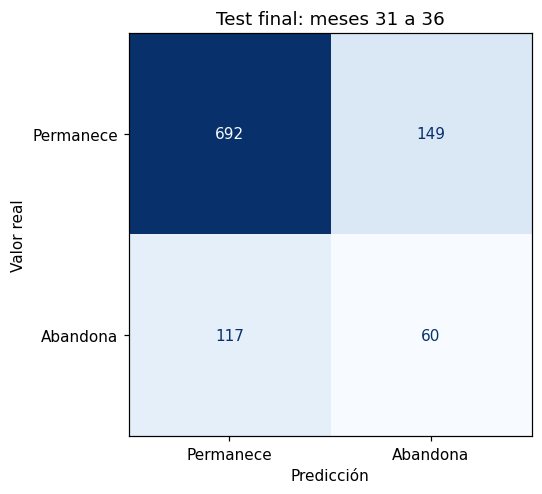

In [21]:
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ConfusionMatrixDisplay.from_predictions(
    y_final,
    pred_final,
    display_labels=["Permanece", "Abandona"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Test final: meses 31 a 36")
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()


En los meses finales, el pipeline obtiene F1 `0,311`: detecta 60 abandonos, omite 117 y produce 149 falsas alertas. La matriz de confusión devuelve la evaluación al contexto. Precision, recall y F1 resumen, pero los falsos positivos y negativos representan acciones u omisiones diferentes.


## 14. Revisar errores individuales

Construiremos una tabla con la clase real, la predicción y la probabilidad. Separaremos falsos positivos y falsos negativos, y observaremos los errores en los que el modelo estaba más seguro.


In [22]:
revision = X_final.copy()
revision["mes"] = test_final["mes"].to_numpy()
revision["real"] = y_final.to_numpy()
revision["prediccion"] = pred_final
revision["probabilidad_abandono"] = proba_final
revision["tipo_resultado"] = np.select(
    [
        (revision["real"] == 1) & (revision["prediccion"] == 1),
        (revision["real"] == 0) & (revision["prediccion"] == 0),
        (revision["real"] == 0) & (revision["prediccion"] == 1),
        (revision["real"] == 1) & (revision["prediccion"] == 0),
    ],
    ["VP", "VN", "FP", "FN"],
    default="",
)
revision["confianza_error"] = np.where(
    revision["prediccion"] == 1,
    revision["probabilidad_abandono"],
    1 - revision["probabilidad_abandono"],
)

print(revision["tipo_resultado"].value_counts())
errores_confiados = (
    revision[revision["tipo_resultado"].isin(["FP", "FN"])]
    .sort_values("confianza_error", ascending=False)
)
errores_confiados.head(10)


tipo_resultado
VN    692
FP    149
FN    117
VP     60
Name: count, dtype: int64


,antiguedad_meses,cargo_mensual,reclamos_6m,tickets_soporte,caida_uso_pct,ingreso_estimado,contrato,canal,mes,real,prediccion,probabilidad_abandono,tipo_resultado,confianza_error
5204,63.500,54.000,1,0,18.300,"1,080.740",Anual,Web,32,1,0,0.065,FN,0.935
5438,46.300,40.180,0,0,18.000,"1,228.770",Bienal,Web,33,1,0,0.104,FN,0.896
5381,29.500,50.960,0,0,20.200,NaN,Anual,Movil,33,1,0,0.105,FN,0.895
5213,53.400,76.730,0,0,14.100,"1,454.080",Anual,Web,32,1,0,0.115,FN,0.885
5934,34.000,55.690,0,1,17.100,"2,208.300",Bienal,Web,36,1,0,0.120,FN,0.880
5297,40.500,43.220,1,1,0.000,"1,459.530",Anual,Web,33,1,0,0.123,FN,0.877
5237,18.000,108.230,0,0,16.700,"1,533.500",Bienal,Web,32,1,0,0.124,FN,0.876
5964,37.800,59.650,1,1,0.700,937.080,Bienal,Telefonico,36,1,0,0.125,FN,0.875
5265,54.300,61.830,0,1,12.900,NaN,Anual,Movil,32,1,0,0.137,FN,0.863
5479,29.200,31.350,0,2,0.600,"1,438.860",Anual,Movil,33,1,0,0.163,FN,0.837


In [23]:
resumen_errores = (
    revision.groupby("tipo_resultado")
    .agg(
        casos=("real", "size"),
        probabilidad_media=("probabilidad_abandono", "mean"),
        reclamos_medios=("reclamos_6m", "mean"),
        caida_uso_media=("caida_uso_pct", "mean"),
        antiguedad_media=("antiguedad_meses", "mean"),
    )
    .reindex(["VP", "VN", "FP", "FN"])
)
resumen_errores


,casos,probabilidad_media,reclamos_medios,caida_uso_media,antiguedad_media
tipo_resultado,,,,,
VP,60,0.635,1.483,26.573,33.155
VN,692,0.284,0.579,13.415,43.162
FP,149,0.615,1.356,24.372,33.042
FN,117,0.325,0.692,15.417,41.225


Las filas no explican por sí solas la causa del error. Funcionan como pistas para revisar etiquetas, faltantes, casos extremos, cambios de contexto y variables insuficientes. Un error confiado merece atención especial, pero tampoco demuestra automáticamente que la etiqueta esté mal.


## 15. Comunicar sin sobreinterpretar

Comparemos una formulación exagerada con una conclusión que describe la evidencia y sus límites.


In [24]:
f1_cv = comparacion_justa.loc[
    comparacion_justa["Modelo"] == mejor_nombre, "F1 medio"
].iloc[0]
f1_test = metricas_finales["F1"].iloc[0]

conclusiones = pd.DataFrame({
    "Tipo": ["Sobreinterpretada", "Responsable"],
    "Conclusión": [
        (
            f"{mejor_nombre} demuestra que podemos anticipar "
            "el abandono de cualquier cliente."
        ),
        (
            f"En estos datos sintéticos, {mejor_nombre} obtuvo "
            f"F1 medio {f1_cv:.3f} durante la validación sobre "
            f"desarrollo y {f1_test:.3f} en los meses finales. "
            "El resultado puede cambiar con otra población, otro "
            "período o variables diferentes; una predicción no "
            "demuestra la causa del abandono."
        ),
    ],
})
pd.set_option("display.max_colwidth", 140)
conclusiones


,Tipo,Conclusión
0,Sobreinterpretada,Random Forest demuestra que podemos anticipar el abandono de cualquier cliente.
1,Responsable,"En estos datos sintéticos, Random Forest obtuvo F1 medio 0.345 durante la validación sobre desarrollo y 0.311 en los meses finales. El r..."


Usar lenguaje prudente no debilita el trabajo. Distingue entre lo observado, lo inferido y lo que todavía no sabemos.


## 16. Actividad modificable

Cambiá `metrica_principal` por `"recall"` o `"accuracy"` y observá si cambia el pipeline seleccionado. Después explicá qué tipo de error prioriza esa decisión y por qué podría ser adecuada —o inadecuada— en un uso real.


In [25]:
metrica_principal = "f1"  # Probar: "f1", "recall" o "accuracy"

actividad = []
for nombre, modelo in modelos_justos.items():
    scores = cross_validate(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring=metrica_principal,
    )["test_score"]
    actividad.append({
        "Modelo": nombre,
        "Métrica": metrica_principal,
        "Promedio": scores.mean(),
        "Desviación": scores.std(),
    })

pd.DataFrame(actividad).sort_values("Promedio", ascending=False)


,Modelo,Métrica,Promedio,Desviación
2,Random Forest,f1,0.345,0.019
0,Regresión logística,f1,0.339,0.014
1,Árbol profundidad 5,f1,0.057,0.042


## 17. Lista de revisión antes de confiar

Antes de presentar un modelo, conviene poder responder:

1. ¿Los casos usados para evaluar eran realmente no vistos?
2. ¿Cada variable existía en el momento de predicción?
3. ¿Imputación, escalado, codificación, selección y PCA aprendieron solo desde entrenamiento?
4. ¿La separación respeta grupos y tiempo?
5. ¿La métrica representa el costo de los errores?
6. ¿Los modelos se compararon con los mismos folds y criterios?
7. ¿Se observó la variabilidad y no solo el mejor número?
8. ¿Se revisaron falsos positivos, falsos negativos y casos extremos?
9. ¿El test final se usó una única vez?
10. ¿La conclusión describe alcance, contexto y límites?


## 18. Síntesis

Un modelo puede ejecutar sin errores y aun así producir una evaluación inválida. En este cuaderno comprobamos que memorizar entrenamiento, incluir información posterior, seleccionar variables antes de validar, mirar solo accuracy, mezclar clientes relacionados o ignorar el tiempo puede inflar o distorsionar los resultados.

El flujo corregido no busca el número más llamativo. Reserva una evaluación final, encapsula el preprocesamiento, compara pipelines bajo las mismas condiciones, observa estabilidad, revisa casos concretos y comunica el resultado como evidencia situada. La calidad de un proyecto de Machine Learning depende tanto del procedimiento de evaluación como del algoritmo elegido.


## Para pensar

1. ¿Por qué un F1 perfecto sobre entrenamiento no demuestra que un modelo sea útil?
2. ¿Qué variable de tu propio contexto podría existir después del evento y producir fuga de datos?
3. ¿En qué situación real sería más importante recall que precision, y qué consecuencia tendría esa elección?
4. ¿Por qué separar filas al azar puede ser incorrecto cuando hay varias observaciones de una misma persona o entidad?
5. ¿Cómo redactarías una conclusión que informe un buen resultado sin presentarlo como una verdad universal?
